# Importar librerías

In [21]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    matthews_corrcoef, 
    precision_score,
    recall_score, 
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Cargar recursos

In [3]:
# Ruta al directorio donde se encuentran los resultados de la experimentación
OUTPUT_FOLDER = Path("../../outputs/runs")

## LOF por dispositivo

In [4]:
# Ruta al diretorio donde se encuentran los resultados de la experimentación de LOF por dispositivo
LOF_OUTPUT_FOLDER = OUTPUT_FOLDER / "nbaiot_lof_per_device_stage_2" / "devices"

In [5]:
# Rutas a los archivos de predicciones de cada modelo LOF por dispositivo
LOF_DEVICE_1_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_1" / "test_predictions.parquet"
LOF_DEVICE_2_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_2" / "test_predictions.parquet"
LOF_DEVICE_3_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_3" / "test_predictions.parquet"
LOF_DEVICE_4_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_4" / "test_predictions.parquet"
LOF_DEVICE_5_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_5" / "test_predictions.parquet"
LOF_DEVICE_6_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_6" / "test_predictions.parquet"
LOF_DEVICE_7_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_7" / "test_predictions.parquet"
LOF_DEVICE_8_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_8" / "test_predictions.parquet"
LOF_DEVICE_9_OUPUT_PATH = LOF_OUTPUT_FOLDER / "device_9" / "test_predictions.parquet"

In [6]:
lof_results_df = pd.concat(
    [
        pd.read_parquet(LOF_DEVICE_1_OUPUT_PATH).assign(device_id=1),
        pd.read_parquet(LOF_DEVICE_2_OUPUT_PATH).assign(device_id=2),
        pd.read_parquet(LOF_DEVICE_3_OUPUT_PATH).assign(device_id=3),
        pd.read_parquet(LOF_DEVICE_4_OUPUT_PATH).assign(device_id=4),
        pd.read_parquet(LOF_DEVICE_5_OUPUT_PATH).assign(device_id=5),
        pd.read_parquet(LOF_DEVICE_6_OUPUT_PATH).assign(device_id=6),
        pd.read_parquet(LOF_DEVICE_7_OUPUT_PATH).assign(device_id=7),
        pd.read_parquet(LOF_DEVICE_8_OUPUT_PATH).assign(device_id=8),
        pd.read_parquet(LOF_DEVICE_9_OUPUT_PATH).assign(device_id=9)
    ],
    ignore_index=True
)

## Autoencoder por dispositivo

In [7]:
# Ruta al diretorio donde se encuentran los resultados de la experimentación de Autoencoder por dispositivo
AE_DEVICE_OUTPUT_FOLDER = OUTPUT_FOLDER / "nbaiot_autoencoder_per_device_stage_3" / "devices"

In [8]:
# Rutas a los archivos de predicciones de cada modelo Autoencoder por dispositivo
AE_DEVICE_1_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_1" / "test_predictions.parquet"
AE_DEVICE_2_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_2" / "test_predictions.parquet"
AE_DEVICE_3_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_3" / "test_predictions.parquet"
AE_DEVICE_4_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_4" / "test_predictions.parquet"
AE_DEVICE_5_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_5" / "test_predictions.parquet"
AE_DEVICE_6_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_6" / "test_predictions.parquet"
AE_DEVICE_7_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_7" / "test_predictions.parquet"
AE_DEVICE_8_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_8" / "test_predictions.parquet"
AE_DEVICE_9_OUTPUT_PATH = AE_DEVICE_OUTPUT_FOLDER / "device_9" / "test_predictions.parquet"

In [9]:
ae_device_results_df = pd.concat(
    [
        pd.read_parquet(AE_DEVICE_1_OUTPUT_PATH).assign(device_id=1),
        pd.read_parquet(AE_DEVICE_2_OUTPUT_PATH).assign(device_id=2),
        pd.read_parquet(AE_DEVICE_3_OUTPUT_PATH).assign(device_id=3),
        pd.read_parquet(AE_DEVICE_4_OUTPUT_PATH).assign(device_id=4),
        pd.read_parquet(AE_DEVICE_5_OUTPUT_PATH).assign(device_id=5),
        pd.read_parquet(AE_DEVICE_6_OUTPUT_PATH).assign(device_id=6),
        pd.read_parquet(AE_DEVICE_7_OUTPUT_PATH).assign(device_id=7),
        pd.read_parquet(AE_DEVICE_8_OUTPUT_PATH).assign(device_id=8),
        pd.read_parquet(AE_DEVICE_9_OUTPUT_PATH).assign(device_id=9)
    ],
    ignore_index=True
)

## Autoencoder global

In [10]:
# Ruta del archivo parquet donde se encuentran los resultados de la experimentación de Autoencoder global
AE_GLOBAL_OUTPUT_PATH = OUTPUT_FOLDER / "nbaiot_autoencoder_global_stage_3" / "test_predictions.parquet"

In [11]:
ae_global_results_df = pd.read_parquet(AE_GLOBAL_OUTPUT_PATH)

## Agrupación de resultados

In [12]:
ae_device_results_df.rename(columns={"reconstruction_error": "score"}, inplace=True)
ae_global_results_df.rename(columns={"reconstruction_error": "score"}, inplace=True)

comparison_df = pd.concat(
    [
        lof_results_df.assign(strategy="LOF"),
        ae_device_results_df.assign(strategy="AE por dispositivo"),
        ae_global_results_df.assign(strategy="AE global"),
    ],
    ignore_index=True
)

comparison_df["device_id"] = (
    comparison_df["device_id"]
    .astype(str)
    .astype(int)
)

# Analizar resultados

En la etapa previa del estudio de los resultados se ha realizado un análisis individual del comportamiento de cada una de las estrategias de detección de anomalías propuestas para redes IoT. Dicho análisis ha permitido estudiar en detalle las fortalezas, limitaciones y características particulares de cada aproximación de forma independiente.

El objetivo de este cuaderno es realizar una comparación directa entre las 3 estrategias desarrolladas a lo largo del trabajo: 

- Un modelo **Local Outlier Factor (LOF)** entrenado por dispositivo
- Un **autoencoder entrenado por dispositivo** 
- Un **autoencoder global** entrenado con el tráfico conjunto de toda la red IoT. 

Para garantizar la validez de la comparación, todas las estrategias han sido entrenadas y evaluadas siguiendo el mismo protocolo experimental, utilizando las mismas particiones de entrenamiento, validación y test, así como procedimientos homogéneos para la selección de los umbrales de decisión. De este modo, las diferencias observadas pueden atribuirse al propio comportamiento de cada estrategia y no a variaciones en el proceso experimental.

No obstante, la comparación entre modelos requiere distinguir 2 perspectivas complementarias:

1. Resulta necesario analizar la **capacidad discriminativa** de cada estrategia utilizando todas las muestras disponibles del conjunto de evaluación, lo que permite estudiar su capacidad para separar tráfico benigno y malicioso independientemente del escenario de despliegue. 
2. El conjunto de test del dataset N-BaIoT presenta una distribución muy diferente a la que cabría esperar en un entorno real, ya que contiene una proporción significativamente mayor de tráfico de ataque que de tráfico benigno. Por este motivo, también se evalúa el comportamiento de las estrategias bajo **distintas prevalencias de ataque**, simulando escenarios de operación más representativos de una infraestructura IoT en producción.

Con esta organización, la comparativa se estructura en tres bloques principales:

- **Capacidad discriminativa**, donde se analiza el potencial de cada estrategia para diferenciar tráfico benigno y malicioso, así como el margen de mejora que ofrece la selección del umbral de decisión.
- **Comportamiento bajo distintas prevalencias de ataque**, donde se estudia cómo evolucionan las principales métricas de rendimiento al aproximar la distribución de datos a la de un entorno IoT real.
- **Escalabilidad y coste de despliegue**, donde se comparan los requisitos de almacenamiento, inferencia y mantenimiento necesarios para operar cada estrategia en redes IoT de distinto tamaño.

En conjunto, este análisis pretende responder a la siguiente cuestión:

> **¿Qué estrategia ofrece el mejor equilibrio entre capacidad de detección, comportamiento en escenarios de operación realistas y coste de despliegue para un sistema de detección de anomalías en infraestructuras IoT?**

In [16]:
STRATEGY_ORDER = ["LOF", "AE por dispositivo", "AE global"]

STRATEGY_COLORS = {
    "LOF": "#BE27F5",
    "AE por dispositivo": "#F5F527",
    "AE global": "#55A868",
}

## 1. Capacidad discriminativa

El primer aspecto analizado en esta comparativa es la capacidad discriminativa de las 3 estrategias propuestas. Este análisis tiene como objetivo evaluar hasta qué punto cada una de ellas es capaz de diferenciar el tráfico benigno del tráfico malicioso, independientemente de las condiciones particulares de despliegue o de la distribución de las muestras presentes en el conjunto de evaluación.

Para ello, este apartado se divide en 2 análisis complementarios.

In [13]:
def compute_binary_metrics(df):
    y_true = df["y_true"].astype(int)
    y_pred = df["y_pred"].astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return pd.Series({
        "mcc": matthews_corrcoef(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    })

### 1.1 Comparativa del rendimiento con los umbrales seleccionados con muestras benignas

Como primer paso, se comparan las 3 estrategias utilizando los umbrales de decisión seleccionados durante el proceso de experimentación. En todos los casos, dichos umbrales fueron estimados exclusivamente a partir de muestras de tráfico benigno, siguiendo una metodología no supervisada coherente con la filosofía de un sistema de detección de anomalías.

El objetivo de este análisis es comparar el rendimiento alcanzado por las distintas estrategias utilizando los umbrales de decisión finalmente seleccionados mediante dicho procedimiento. De este modo, todas las estrategias son evaluadas bajo condiciones equivalentes, permitiendo que las diferencias observadas sean atribuibles al propio comportamiento del modelo y no a un ajuste supervisado del punto de operación.

La comparación se realiza empleando 3 métricas complementarias, cada una de ellas orientada a evaluar un aspecto diferente del rendimiento del detector:

- **Matthews Correlation Coefficient (MCC):** se utiliza como métrica principal de rendimiento global debido a que considera simultáneamente verdaderos y falsos positivos y negativos, proporcionando una evaluación robusta incluso cuando existe un fuerte desbalanceo entre las clases.

- **Recall:** mide la capacidad del detector para identificar correctamente las muestras de tráfico malicioso. Esta métrica permite cuantificar la proporción de ataques detectados por cada estrategia.

- **False Positive Rate (FPR):** cuantifica la proporción de muestras benignas clasificadas erróneamente como ataques. Dado que las falsas alarmas representan uno de los principales problemas operativos de un sistema de detección de anomalías, esta métrica resulta fundamental para evaluar la viabilidad práctica de cada estrategia.

Finalmente, el análisis se presenta tanto de forma global como desagregado por dispositivo y por familia/tipo de ataque, permitiendo identificar diferencias de comportamiento entre las distintas estrategias desde distintos niveles de detalle.

In [29]:
global_metrics_df = (
    comparison_df
    .groupby("strategy", observed=True)
    .apply(compute_binary_metrics)
    .reset_index()
)

global_metrics_df["strategy"] = pd.Categorical(
    global_metrics_df["strategy"],
    categories=STRATEGY_ORDER,
    ordered=True
)

global_metrics_df = (
    global_metrics_df
    .sort_values("strategy")
    [["strategy", "mcc", "recall", "fpr"]]
)

display(
    global_metrics_df
    .style
    .format({
        "mcc": "{:.4f}",
        "recall": "{:.4f}",
        "fpr": "{:.4f}",
    })
)

,strategy,mcc,recall,fpr
2,LOF,0.2179,0.7531,0.0100
1,AE por dispositivo,0.2178,0.7530,0.0103
0,AE global,0.2019,0.7224,0.0098


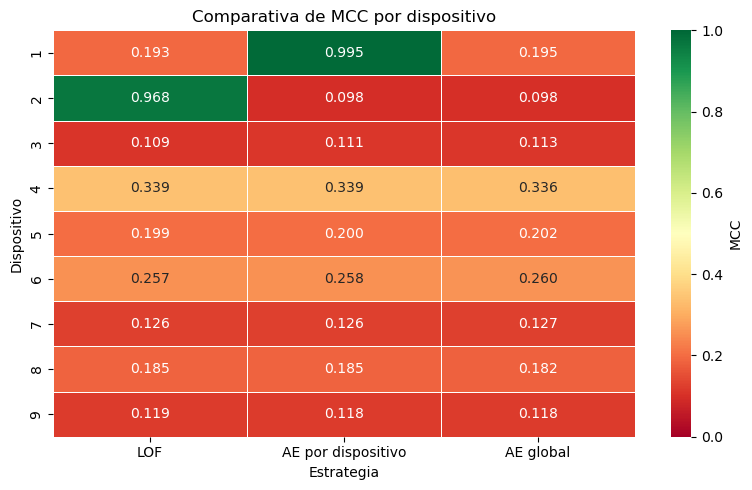

In [39]:
device_metrics_df = (
    comparison_df
    .groupby(["device_id", "strategy"], observed=True)
    .apply(compute_binary_metrics)
    .reset_index()
)

device_metrics_df["strategy"] = pd.Categorical(
    device_metrics_df["strategy"],
    categories=STRATEGY_ORDER,
    ordered=True
)

device_mcc_matrix = (
    device_metrics_df
    .pivot(index="device_id", columns="strategy", values="mcc")
    .reindex(columns=STRATEGY_ORDER)
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    device_mcc_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "MCC"}
)

plt.title("Comparativa de MCC por dispositivo")
plt.xlabel("Estrategia")
plt.ylabel("Dispositivo")
plt.tight_layout()
plt.show()

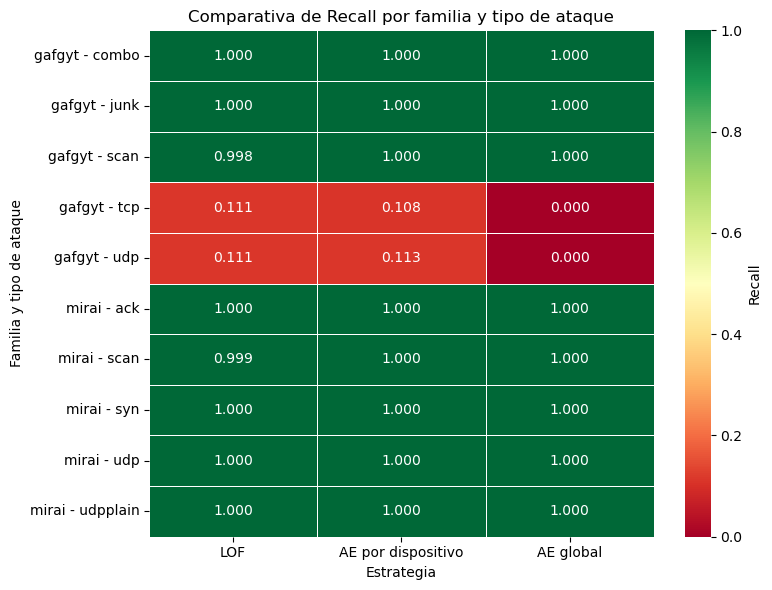

In [40]:
attack_df = comparison_df[comparison_df["y_true"] == 1].copy()

attack_metrics_df = (
    attack_df
    .groupby(["attack_family", "attack_type", "strategy"], observed=True)
    .apply(compute_binary_metrics)
    .reset_index()
)

attack_metrics_df["strategy"] = pd.Categorical(
    attack_metrics_df["strategy"],
    categories=STRATEGY_ORDER,
    ordered=True
)

attack_metrics_df["attack"] = (
    attack_metrics_df["attack_family"].astype(str)
    + " - "
    + attack_metrics_df["attack_type"].astype(str)
)

attack_recall_matrix = (
    attack_metrics_df
    .pivot(index="attack", columns="strategy", values="recall")
    .reindex(columns=STRATEGY_ORDER)
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    attack_recall_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Recall"}
)

plt.title("Comparativa de Recall por familia y tipo de ataque")
plt.xlabel("Estrategia")
plt.ylabel("Familia y tipo de ataque")
plt.tight_layout()
plt.show()

Los resultados obtenidos muestran que, utilizando umbrales de decisión seleccionados exclusivamente a partir de muestras benignas, las 3 estrategias presentan un comportamiento global muy similar. Tanto **LOF** como el **autoencoder por dispositivo** alcanzan valores prácticamente idénticos de **MCC**, **recall** y **FPR**, mientras que el **autoencoder global** experimenta una ligera disminución del rendimiento global.

El análisis por dispositivo revela que las diferencias entre estrategias son, en general, reducidas y que el comportamiento del detector depende en gran medida del dispositivo monitorizado. Salvo casos concretos, ninguna estrategia muestra una ventaja consistente sobre las demás cuando se emplean los umbrales seleccionados mediante un procedimiento completamente no supervisado.

Por otro lado, el análisis por familia y tipo de ataque pone de manifiesto que la pérdida de rendimiento se concentra casi exclusivamente en los ataques **Gafgyt TCP** y **Gafgyt UDP**, mientras que el resto de ataques son detectados con valores de *recall* próximos a la unidad por las 3 estrategias. Este resultado sugiere que las diferencias observadas en las métricas globales no se deben a un comportamiento homogéneo frente a todos los ataques, sino a la dificultad que presentan un número muy reducido de ellos.

En conjunto, este primer análisis muestra que las 3 estrategias ofrecen un rendimiento comparable cuando operan con umbrales obtenidos únicamente a partir de tráfico benigno. No obstante, estos resultados no permiten determinar si dichas similitudes responden a una capacidad discriminativa equivalente o, por el contrario, a limitaciones derivadas del criterio de selección del umbral. Esta cuestión se aborda en el siguiente apartado mediante el estudio del potencial de discriminación de cada estrategia y su capacidad para mejorar el punto de operación del detector.

### 1.2 Potencial de discriminación de las estrategias

El análisis del apartado anterior ha permitido comparar el rendimiento alcanzado por las 3 estrategias utilizando los umbrales de decisión seleccionados mediante un procedimiento completamente no supervisado. Sin embargo, dichas métricas reflejan únicamente el comportamiento del detector en un punto de operación concreto y no permiten evaluar la capacidad intrínseca del modelo para separar las muestras benignas de las maliciosas.

Con el objetivo de analizar esta capacidad discriminativa, en este apartado se comparan las curvas **Receiver Operating Characteristic (ROC)** de las 3 estrategias. A diferencia de las métricas obtenidas para un único umbral, las curvas ROC representan el comportamiento del detector para todos los posibles puntos de operación, permitiendo evaluar la calidad de la separación entre ambas clases de forma independiente del criterio utilizado para seleccionar el umbral de decisión.

Este análisis resulta especialmente relevante para determinar si un determinado modelo podría mejorar su rendimiento mediante un ajuste supervisado del umbral utilizando un conjunto reducido de muestras etiquetadas, aspecto que se estudia de forma indirecta a través de la capacidad discriminativa mostrada por cada estrategia.

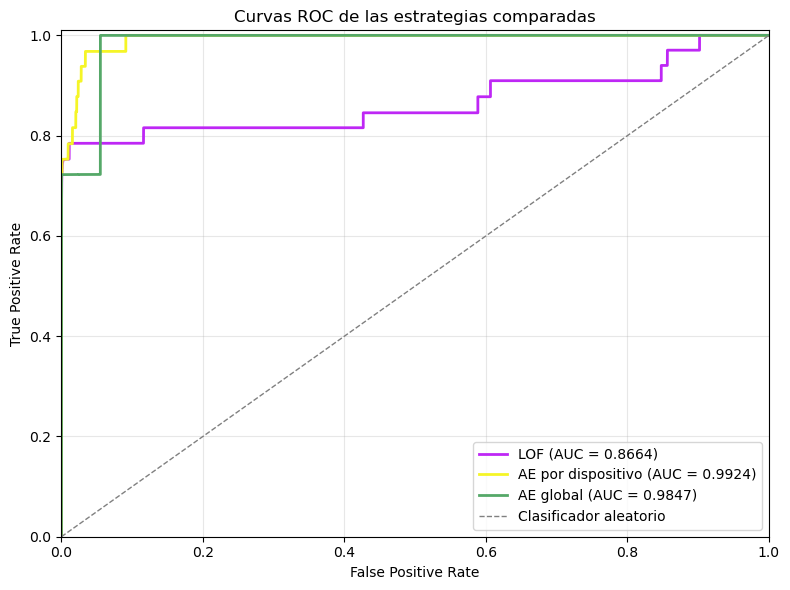

In [41]:
plt.figure(figsize=(8, 6))

for strategy in STRATEGY_ORDER:
    strategy_df = comparison_df[comparison_df["strategy"] == strategy].copy()

    y_true = strategy_df["y_true"].astype(int)
    y_score = strategy_df["score"].astype(float)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.plot(
        fpr,
        tpr,
        label=f"{strategy} (AUC = {auc:.4f})",
        color=STRATEGY_COLORS[strategy],
        linewidth=2
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Clasificador aleatorio"
)

plt.title("Curvas ROC de las estrategias comparadas")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 1)
plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Las curvas ROC muestran diferencias muy significativas entre las estrategias analizadas. Mientras que **LOF** obtiene un **AUC de 0.8664**, ambos autoencoders alcanzan valores próximos a la unidad (**0.9924** para el autoencoder por dispositivo y **0.9847** para el autoencoder global), evidenciando una capacidad muy superior para separar las muestras benignas de las maliciosas.

Este resultado contrasta con el análisis realizado en el apartado anterior, donde las diferencias entre estrategias utilizando los umbrales seleccionados a partir de muestras benignas eran relativamente reducidas. La comparación entre ambos análisis pone de manifiesto que el rendimiento observado con un determinado umbral no refleja necesariamente la capacidad discriminativa real del modelo.

En el caso de los autoencoders, la elevada área bajo la curva ROC indica que existe un amplio margen para mejorar el punto de operación mediante un ajuste supervisado del umbral utilizando muestras etiquetadas, ya que los errores de reconstrucción de ambas clases presentan una separación considerable. Por el contrario, la menor capacidad discriminativa mostrada por LOF sugiere que este margen de mejora es mucho más limitado, al existir un mayor solapamiento entre las puntuaciones asignadas al tráfico benigno y al tráfico malicioso.

En consecuencia, este análisis evidencia que los autoencoders no solo ofrecen una representación más discriminativa del comportamiento de la red IoT, sino que también poseen un mayor potencial para optimizar su rendimiento cuando se dispone de información supervisada para ajustar el umbral de decisión. No obstante, esta mayor capacidad discriminativa no garantiza que el umbral obtenido mantenga su comportamiento cuando cambie la distribución de las clases, cuestión que será analizada en el siguiente apartado mediante la evaluación bajo distintas prevalencias de ataque.

## 2. Comportamiento en escenarios operativos realistas

El análisis de la capacidad discriminativa realizado en el apartado anterior permite evaluar el potencial de separación entre tráfico benigno y malicioso de cada estrategia. Sin embargo, el rendimiento de un sistema de detección de anomalías no depende únicamente de dicha capacidad, sino también del contexto en el que opera. En este apartado se estudia cómo evoluciona el comportamiento de las distintas estrategias cuando la distribución entre tráfico benigno y de ataque se aproxima progresivamente a la que cabría esperar en una infraestructura IoT real, prestando especial atención al impacto que la prevalencia de ataque tiene sobre las principales métricas de rendimiento.

In [ ]:
PREVALENCES = [0.001, 0.005, 0.01, 0.05, 0.10]

PREVALENCE_LABELS = {
    0.001: "0.1%",
    0.005: "0.5%",
    0.01: "1%",
    0.05: "5%",
    0.10: "10%",
}

RANDOM_STATE = 42

### 2.1 Influencia de la prevalencia de ataque

El conjunto de evaluación original del dataset N-BaIoT presenta una proporción de tráfico de ataque significativamente superior a la que cabría esperar en un entorno IoT real. Con el objetivo de analizar el comportamiento operacional de las distintas estrategias bajo condiciones más representativas, se evalúa su rendimiento considerando cinco prevalencias de ataque diferentes: **0.1%, 0.5%, 1%, 5% y 10%**.

Para cada escenario se mantiene constante la totalidad del tráfico benigno disponible y se ajusta únicamente el número de muestras de ataque, permitiendo estudiar de forma aislada el efecto que la prevalencia tiene sobre las métricas de rendimiento. La comparación se realiza mediante **Precision**, **Recall** y **MCC**, ya que permiten analizar, respectivamente, la fiabilidad de las alertas generadas, la capacidad de detección de ataques y el rendimiento global del detector en escenarios con fuerte desbalanceo entre clases.

In [19]:
def sample_strategy_by_prevalence(
    df,
    prevalence,
    random_state=42
):
    benign_df = df[df["y_true"] == 0].copy()
    attack_df = df[df["y_true"] == 1].copy()

    n_benign = len(benign_df)
    n_attack = int(round((prevalence / (1 - prevalence)) * n_benign))

    if n_attack > len(attack_df):
        raise ValueError(
            f"No hay suficientes muestras de ataque para prevalencia={prevalence}. "
            f"Necesarias: {n_attack}, disponibles: {len(attack_df)}"
        )

    sampled_attack = attack_df.sample(
        n=n_attack,
        replace=False,
        random_state=random_state,
    )

    sampled_df = (
        pd.concat([benign_df, sampled_attack], ignore_index=True)
        .sample(frac=1, random_state=random_state + 1)
        .reset_index(drop=True)
    )

    return sampled_df


def compute_operational_metrics(df):
    y_true = df["y_true"].astype(int)
    y_pred = df["y_pred"].astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "fp_per_100k_benign": (fp / (fp + tn) * 100_000) if (fp + tn) > 0 else 0.0,
    }

In [24]:
operational_results = []

for strategy in STRATEGY_ORDER:
    strategy_df = comparison_df[comparison_df["strategy"] == strategy].copy()

    for prevalence in PREVALENCES:
        sampled_df = sample_strategy_by_prevalence(
            strategy_df,
            prevalence=prevalence,
            random_state=RANDOM_STATE,
        )

        metrics = compute_operational_metrics(sampled_df)

        operational_results.append({
            "strategy": strategy,
            "prevalence": prevalence,
            "prevalence_label": PREVALENCE_LABELS[prevalence],
            **metrics,
        })

operational_metrics_df = pd.DataFrame(operational_results)

operational_metrics_df["strategy"] = pd.Categorical(
    operational_metrics_df["strategy"],
    categories=STRATEGY_ORDER,
    ordered=True,
)

operational_metrics_df["prevalence_label"] = pd.Categorical(
    operational_metrics_df["prevalence_label"],
    categories=[PREVALENCE_LABELS[p] for p in PREVALENCES],
    ordered=True,
)

operational_metrics_df = operational_metrics_df.sort_values(
    ["strategy", "prevalence"]
)

In [25]:
display(
    operational_metrics_df[
        ["strategy", "prevalence_label", "precision", "recall", "mcc", "fpr", "fp_per_100k_benign"]
    ]
    .style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "mcc": "{:.4f}",
        "fpr": "{:.4f}",
        "fp_per_100k_benign": "{:.1f}",
    })
)

,strategy,prevalence_label,precision,recall,mcc,fpr,fp_per_100k_benign
0,LOF,0.1%,0.0680,0.7297,0.2208,0.0100,998.3
1,LOF,0.5%,0.2764,0.7585,0.4538,0.0100,998.3
2,LOF,1%,0.4299,0.7453,0.5605,0.0100,998.3
3,LOF,5%,0.8006,0.7614,0.7695,0.0100,998.3
4,LOF,10%,0.8943,0.7604,0.8071,0.0100,998.3
5,AE por dispositivo,0.1%,0.0692,0.7658,0.2283,0.0103,1028.0
6,AE por dispositivo,0.5%,0.2747,0.7746,0.4573,0.0103,1028.0
7,AE por dispositivo,1%,0.4259,0.7551,0.5616,0.0103,1028.0
8,AE por dispositivo,5%,0.7961,0.7625,0.7677,0.0103,1028.0
9,AE por dispositivo,10%,0.8917,0.7620,0.8067,0.0103,1028.0


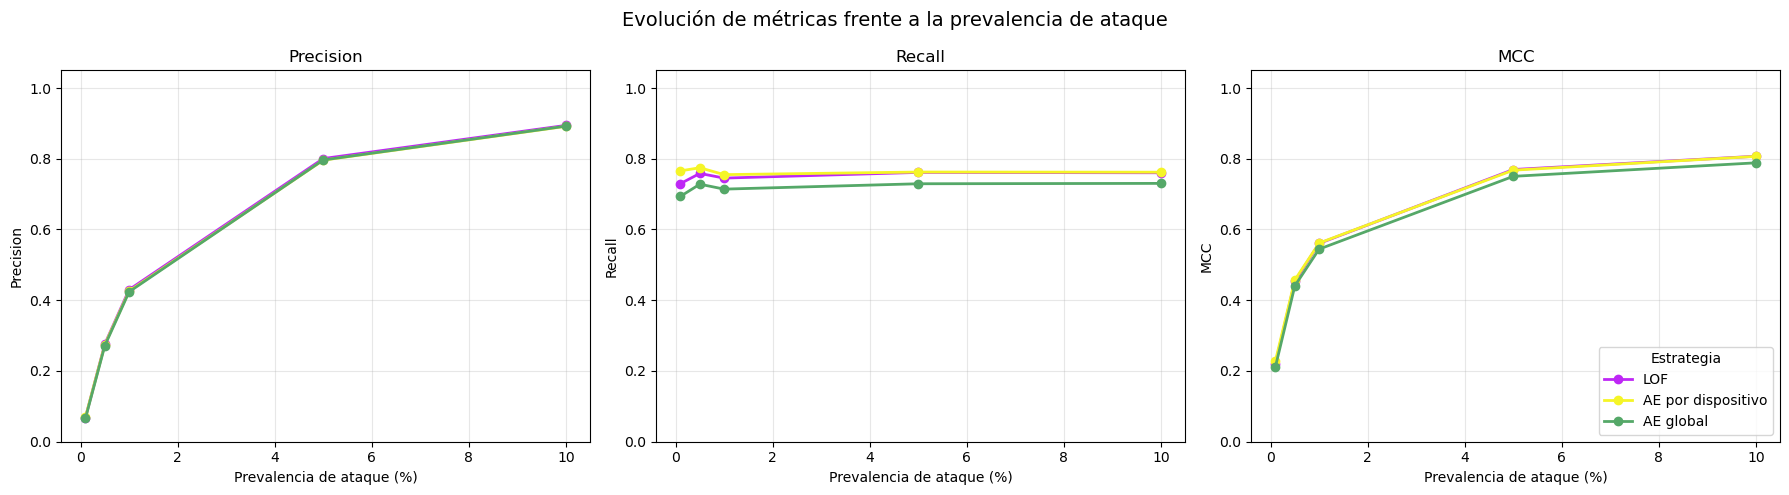

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

metrics_to_plot = [
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("mcc", "MCC"),
]

for ax, (metric, title) in zip(axes, metrics_to_plot):
    for strategy in STRATEGY_ORDER:
        plot_df = operational_metrics_df[
            operational_metrics_df["strategy"] == strategy
        ]

        ax.plot(
            plot_df["prevalence"] * 100,
            plot_df[metric],
            marker="o",
            linewidth=2,
            label=strategy,
            color=STRATEGY_COLORS[strategy],
        )

    ax.set_title(title)
    ax.set_xlabel("Prevalencia de ataque (%)")
    ax.set_ylabel(title)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

axes[-1].legend(title="Estrategia", loc="lower right")

plt.suptitle("Evolución de métricas frente a la prevalencia de ataque", fontsize=14)
plt.tight_layout()
plt.show()

Los resultados muestran un comportamiento muy similar para las 3 estrategias frente a las distintas prevalencias evaluadas. La **Precision** disminuye de forma muy acusada a medida que la proporción de ataques se reduce, pasando de valores próximos al **90%** para una prevalencia del **10%** a valores cercanos al **7%** cuando la prevalencia es del **0.1%**. Este comportamiento pone de manifiesto la elevada dependencia de esta métrica respecto a la distribución de las clases, incluso cuando el detector mantiene inalterado su funcionamiento.

Por el contrario, el **Recall** permanece prácticamente constante para todas las prevalencias analizadas. Esto indica que la capacidad de detección de ataques de las 3 estrategias apenas se ve afectada por la distribución del conjunto de evaluación, ya que el porcentaje de ataques correctamente identificados se mantiene estable en todos los escenarios considerados.

El comportamiento del **MCC** resulta coherente con las observaciones anteriores. Aunque disminuye progresivamente conforme la prevalencia de ataque se reduce, dicha degradación es considerablemente menor que la experimentada por la Precision. Este resultado confirma que el MCC constituye una métrica más adecuada para comparar estrategias de detección de anomalías cuando existe un fuerte desbalanceo entre clases, ya que proporciona una visión más estable y representativa del rendimiento global del detector.

Finalmente, cabe destacar que las diferencias entre estrategias continúan siendo reducidas bajo todas las prevalencias evaluadas. Si bien el **autoencoder por dispositivo** mantiene los mejores valores de MCC y Recall, el **autoencoder global** presenta un comportamiento muy próximo al anterior, mientras que **LOF** obtiene resultados similares pese a su menor capacidad discriminativa observada en el apartado previo.

### 2.2 Robustez del ajuste supervisado del umbral

Las métricas analizadas en el apartado anterior permiten cuantificar cómo evoluciona el rendimiento de cada estrategia cuando cambia la prevalencia de ataque. No obstante, al igual que ocurría con las curvas ROC en el análisis de capacidad discriminativa, resulta de interés estudiar el comportamiento del detector para la totalidad de los posibles umbrales de decisión.

Con este objetivo, se comparan las curvas **Precision-Recall (PR)** correspondientes a los 2 escenarios extremos considerados en este trabajo:

- Prevalencia de ataque del **10%**, representativa del caso más favorable analizado
- Prevalencia del **0.1%**, correspondiente al escenario más exigente. 

A diferencia de las curvas ROC, las curvas PR sí reflejan el efecto del desbalanceo entre clases, permitiendo visualizar cómo varía el compromiso entre precisión y capacidad de detección cuando disminuye la proporción de tráfico malicioso.

In [27]:
PR_PREVALENCES = [0.001, 0.10]

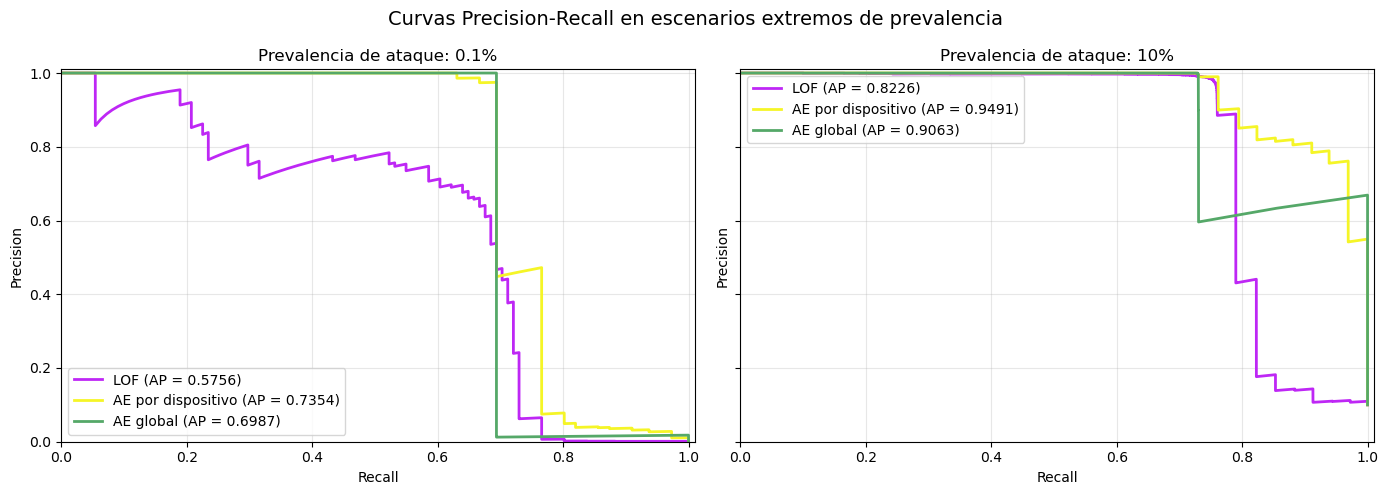

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, prevalence in zip(axes, PR_PREVALENCES):
    for strategy in STRATEGY_ORDER:
        strategy_df = comparison_df[comparison_df["strategy"] == strategy].copy()

        sampled_df = sample_strategy_by_prevalence(
            strategy_df,
            prevalence=prevalence,
            random_state=RANDOM_STATE,
        )

        y_true = sampled_df["y_true"].astype(int)
        y_score = sampled_df["score"].astype(float)

        precision, recall, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)

        ax.plot(
            recall,
            precision,
            linewidth=2,
            label=f"{strategy} (AP = {ap:.4f})",
            color=STRATEGY_COLORS[strategy],
        )

    ax.set_title(f"Prevalencia de ataque: {PREVALENCE_LABELS[prevalence]}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Curvas Precision-Recall en escenarios extremos de prevalencia", fontsize=14)
plt.tight_layout()
plt.show()

Las curvas Precision-Recall confirman las conclusiones obtenidas en el apartado anterior y permiten comprender con mayor profundidad el efecto de la prevalencia sobre el comportamiento de las distintas estrategias. En ambos escenarios, los autoencoders presentan curvas claramente superiores a la de **LOF**, siendo el **autoencoder por dispositivo** el que alcanza la mayor **Average Precision (AP)**, seguido del **autoencoder global**.

Cuando la prevalencia de ataque es del **10%**, las 3 estrategias mantienen valores elevados de precisión para un amplio rango de *recall*, aunque las diferencias entre ellas ya comienzan a apreciarse. Sin embargo, al reducir la prevalencia hasta el **0.1%**, la degradación de la precisión resulta mucho más acusada, especialmente para **LOF**, cuya curva se aleja considerablemente de las obtenidas por ambos autoencoders.

Estos resultados ponen de manifiesto que la disminución observada en la Precision no constituye una limitación exclusiva de una estrategia concreta, sino una consecuencia directa del incremento del desbalanceo entre clases. No obstante, también evidencian que la mayor capacidad discriminativa de los autoencoders, observada previamente mediante las curvas ROC, se traduce en un mejor compromiso entre precisión y capacidad de detección cuando se consideran todos los posibles umbrales de decisión.

En conjunto, este análisis confirma que la interpretación del rendimiento de un sistema de detección de anomalías debe realizarse siempre teniendo en cuenta la prevalencia esperada de ataques en el entorno de operación. De lo contrario, métricas como la Precision pueden conducir a conclusiones erróneas sobre el comportamiento real de las distintas estrategias.

## 3. Coste de despliegue y mantenimiento

Además del rendimiento obtenido por cada estrategia, la elección de un sistema de detección de anomalías para una infraestructura IoT debe considerar el coste asociado a su despliegue y mantenimiento. En entornos reales, caracterizados por un número elevado y cambiante de dispositivos, aspectos como el número de modelos y umbrales que deben gestionarse, el espacio de almacenamiento requerido o la facilidad para incorporar nuevos dispositivos pueden resultar tan relevantes como las propias métricas de detección.

Con el objetivo de complementar el análisis realizado en los apartados anteriores, en esta sección se comparan los principales requisitos operativos de las tres estrategias propuestas, permitiendo valorar las implicaciones prácticas que tendría su utilización en un escenario de despliegue real.

In [29]:
cost_df = pd.DataFrame(
    {
        "Aspecto": [
            "Nº de modelos",
            "Nº de umbrales",
            "Tamaño en disco (MB)",
            "Velocidad de inferencia",
            "Incorporación de nuevos dispositivos",
            "Coste de mantenimiento",
        ],
        "LOF": [
            9,
            9,
            187.9103,
            "N/D",
            "Entrenar un nuevo modelo y seleccionar un nuevo umbral",
            "Alto",
        ],
        "AE por dispositivo": [
            9,
            9,
            2.8502,
            "≈ 15 000 muestras/s",
            "Entrenar un nuevo modelo y seleccionar un nuevo umbral",
            "Alto",
        ],
        "AE global": [
            1,
            1,
            0.4909,
            "≈ 15 000 muestras/s",
            "El modelo existente puede utilizarse directamente*",
            "Bajo",
        ],
    }
)

display(cost_df)

,Aspecto,LOF,AE por dispositivo,AE global
0,Nº de modelos,9,9,1
1,Nº de umbrales,9,9,1
2,Tamaño en disco (MB),187.9103,2.8502,0.4909
3,Velocidad de inferencia,N/D,≈ 15 000 muestras/s,≈ 15 000 muestras/s
4,Incorporación de nuevos dispositivos,Entrenar un nuevo modelo y seleccionar un nuev...,Entrenar un nuevo modelo y seleccionar un nuev...,El modelo existente puede utilizarse directame...
5,Coste de mantenimiento,Alto,Alto,Bajo


La comparativa pone de manifiesto diferencias importantes en el coste de despliegue y mantenimiento de las tres estrategias, especialmente en aquellos aspectos relacionados con la escalabilidad de la solución.

En primer lugar, **LOF** constituye la estrategia con mayor coste de almacenamiento, alcanzando un tamaño aproximado de **188 MB**, muy superior al de ambas propuestas basadas en autoencoders. Además, al igual que el autoencoder por dispositivo, requiere mantener un modelo y un umbral independientes para cada dispositivo de la red, lo que incrementa el esfuerzo necesario para incorporar nuevos dispositivos o actualizar la solución.

Por su parte, el **autoencoder por dispositivo** reduce drásticamente el espacio de almacenamiento respecto a LOF, manteniendo además una elevada velocidad de inferencia. Sin embargo, continúa presentando un coste de mantenimiento elevado al necesitar un modelo y un umbral específicos para cada dispositivo monitorizado. En consecuencia, el número de modelos que deben gestionarse crece de forma lineal con el tamaño de la red IoT.

Finalmente, el **autoencoder global** destaca por requerir únicamente **un único modelo y un único umbral** para toda la infraestructura, reduciendo el tamaño ocupado en disco hasta **0.49 MB** sin penalizar la velocidad de inferencia respecto al autoencoder por dispositivo. Esta característica simplifica considerablemente las tareas de despliegue, actualización y mantenimiento de la solución, especialmente en entornos IoT dinámicos donde la incorporación de nuevos dispositivos constituye una situación habitual.

En conjunto, este análisis pone de manifiesto que, aunque las diferencias de rendimiento observadas entre estrategias son relativamente reducidas, las diferencias en cuanto a complejidad de despliegue y mantenimiento resultan significativamente mayores. Por ello, estos aspectos deben considerarse conjuntamente con las métricas de detección antes de seleccionar la estrategia más adecuada para un escenario de aplicación concreto.

## 4. Conclusión

Tras analizar de forma conjunta el rendimiento de las tres estrategias de detección propuestas, los resultados obtenidos ponen de manifiesto que todas ellas son capaces de detectar una proporción elevada de los ataques presentes en el dataset N-BaIoT, aunque presentan diferencias relevantes tanto en su capacidad discriminativa como en los requisitos asociados a su despliegue y mantenimiento.

En primer lugar, la estrategia basada en **LOF** constituye la alternativa con menor rendimiento global. Aunque es capaz de detectar correctamente una parte importante del tráfico malicioso, presenta una capacidad discriminativa inferior a la obtenida mediante los modelos basados en autoencoders, especialmente en escenarios con una prevalencia de ataque reducida. Además, requiere mantener un modelo independiente para cada dispositivo y un mayor espacio de almacenamiento, lo que limita su escalabilidad en infraestructuras IoT de gran tamaño.

Por su parte, el **autoencoder específico por dispositivo** obtiene el mejor rendimiento de detección de las tres estrategias evaluadas. La especialización del modelo para cada dispositivo le permite capturar con mayor precisión el comportamiento normal de cada uno de ellos, alcanzando los mejores valores de Recall, ROC-AUC y Average Precision. Sin embargo, esta mejora viene acompañada de un coste operativo elevado, ya que resulta necesario entrenar, almacenar, actualizar y calibrar un modelo y un threshold independientes para cada dispositivo de la red. En consecuencia, el esfuerzo de mantenimiento crece de forma lineal conforme aumenta el número de dispositivos monitorizados.

Finalmente, el **autoencoder global** presenta un rendimiento ligeramente inferior al obtenido por la estrategia específica por dispositivo, pero mantiene una elevada capacidad de detección y una robustez comparable frente a cambios en la prevalencia del ataque. A cambio, reduce drásticamente la complejidad de despliegue al requerir únicamente un único modelo y un único threshold para toda la infraestructura, simplificando tanto la incorporación de nuevos dispositivos como las tareas de actualización y mantenimiento del sistema.

En conjunto, los resultados ponen de manifiesto un **trade-off** claro entre rendimiento y coste operativo. Mientras que el autoencoder por dispositivo maximiza la capacidad de detección a costa de incrementar significativamente la complejidad de gestión, el autoencoder global sacrifica únicamente una pequeña parte de dicho rendimiento a cambio de una reducción muy importante del coste de despliegue, almacenamiento y mantenimiento. Desde una perspectiva práctica, esta diferencia resulta especialmente relevante en infraestructuras IoT reales, caracterizadas por un número elevado y cambiante de dispositivos.

Por todo ello, considerando de forma conjunta el rendimiento obtenido, la robustez frente a distintas prevalencias de ataque y los requisitos de despliegue y mantenimiento, **la estrategia basada en un autoencoder global constituye la propuesta más equilibrada para su aplicación en entornos IoT reales**, ofreciendo el mejor compromiso entre eficacia en la detección de anomalías y viabilidad operativa a largo plazo.